In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv('/content/amazon_fires.csv',encoding='ISO-8859-1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ano       6454 non-null   int64 
 1   mes       6454 non-null   object
 2   estado    6454 non-null   object
 3   numero    6322 non-null   object
 4   encontro  6454 non-null   object
dtypes: int64(1), object(4)
memory usage: 252.2+ KB


In [85]:
df

,ano,mes,estado,numero,encontro
0,1998,Janeiro,Acre,0 Fires,1/1/1998
1,1999,Janeiro,Acre,0 Fires,1/1/1999
2,2000,Janeiro,Acre,0 Fires,1/1/2000
3,2001,Janeiro,Acre,0 Fires,1/1/2001
4,2002,Janeiro,Acre,0 Fires,1/1/2002
...,...,...,...,...,...
6449,2012,Dezembro,Tocantins,128,1/1/2012
6450,2013,Dezembro,Tocantins,85,1/1/2013
6451,2014,Dezembro,Tocantins,223,1/1/2014
6452,2015,Dezembro,Tocantins,373,1/1/2015


**DATA CLEANING**

In [86]:
d={'ano':'year', 'mes':'month', 'estado':'state', 'numero':'no_of_fires', 'encontro':'dateoffire'}
df.rename(columns=d,inplace=True)
#df.info()
df.drop_duplicates(inplace=True)
m={'Janeiro':'Jan', 'Fevereiro':'Feb', 'Março':'Mar', 'Abril':'April', 'Maio':'May', 'Junho':'June', 'Julho':'July',
       'Agosto':'August', 'Setembro':'Sep', 'Outubro':'Oct', 'Novembro':'Nov', 'Dezembro':'Dec'}
df['month']=df['month'].map(m)
df['no_of_fires']=df['no_of_fires'].str.strip(' Fires')
df['no_of_fires']=df['no_of_fires'].ffill()
df['no_of_fires']=df['no_of_fires'].astype(float)
df.reset_index(inplace=True)
df.drop('index',axis=1,inplace=True)
df['dateoffire']=pd.to_datetime(df['dateoffire'])
df

,year,month,state,no_of_fires,dateoffire
0,1998,Jan,Acre,0.0,1998-01-01
1,1999,Jan,Acre,0.0,1999-01-01
2,2000,Jan,Acre,0.0,2000-01-01
3,2001,Jan,Acre,0.0,2001-01-01
4,2002,Jan,Acre,0.0,2002-01-01
...,...,...,...,...,...
6419,2012,Dec,Tocantins,128.0,2012-01-01
6420,2013,Dec,Tocantins,85.0,2013-01-01
6421,2014,Dec,Tocantins,223.0,2014-01-01
6422,2015,Dec,Tocantins,373.0,2015-01-01


**DATA ANALYSING**

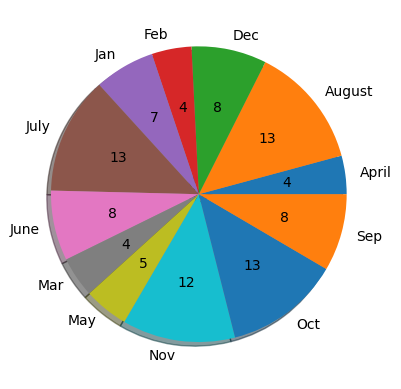

In [87]:
v=df.groupby('month')['no_of_fires'].sum()
v=pd.DataFrame(v)
plt.pie(v['no_of_fires'],labels=v.index,autopct='%0.0f',shadow=True)
plt.show()

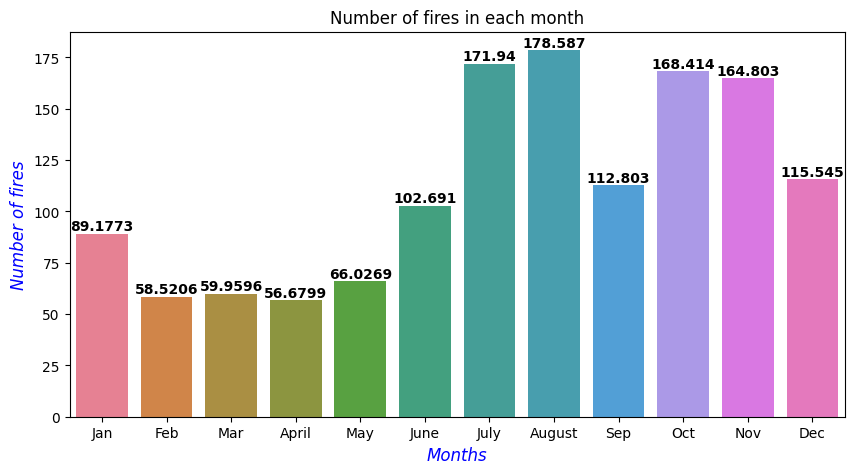

In [88]:
plt.figure(figsize=(10,5))
a=sns.barplot(x='month',y='no_of_fires',data=df,hue='month',errorbar=None)
a.set_xlabel('Months',color='Blue',fontstyle='italic',fontsize=12)
a.set_ylabel('Number of fires',color='Blue',fontstyle='italic',fontsize=12)
a.set_title('Number of fires in each month')


for i in a.containers:
  a.bar_label(i,fontweight='bold')
plt.show()

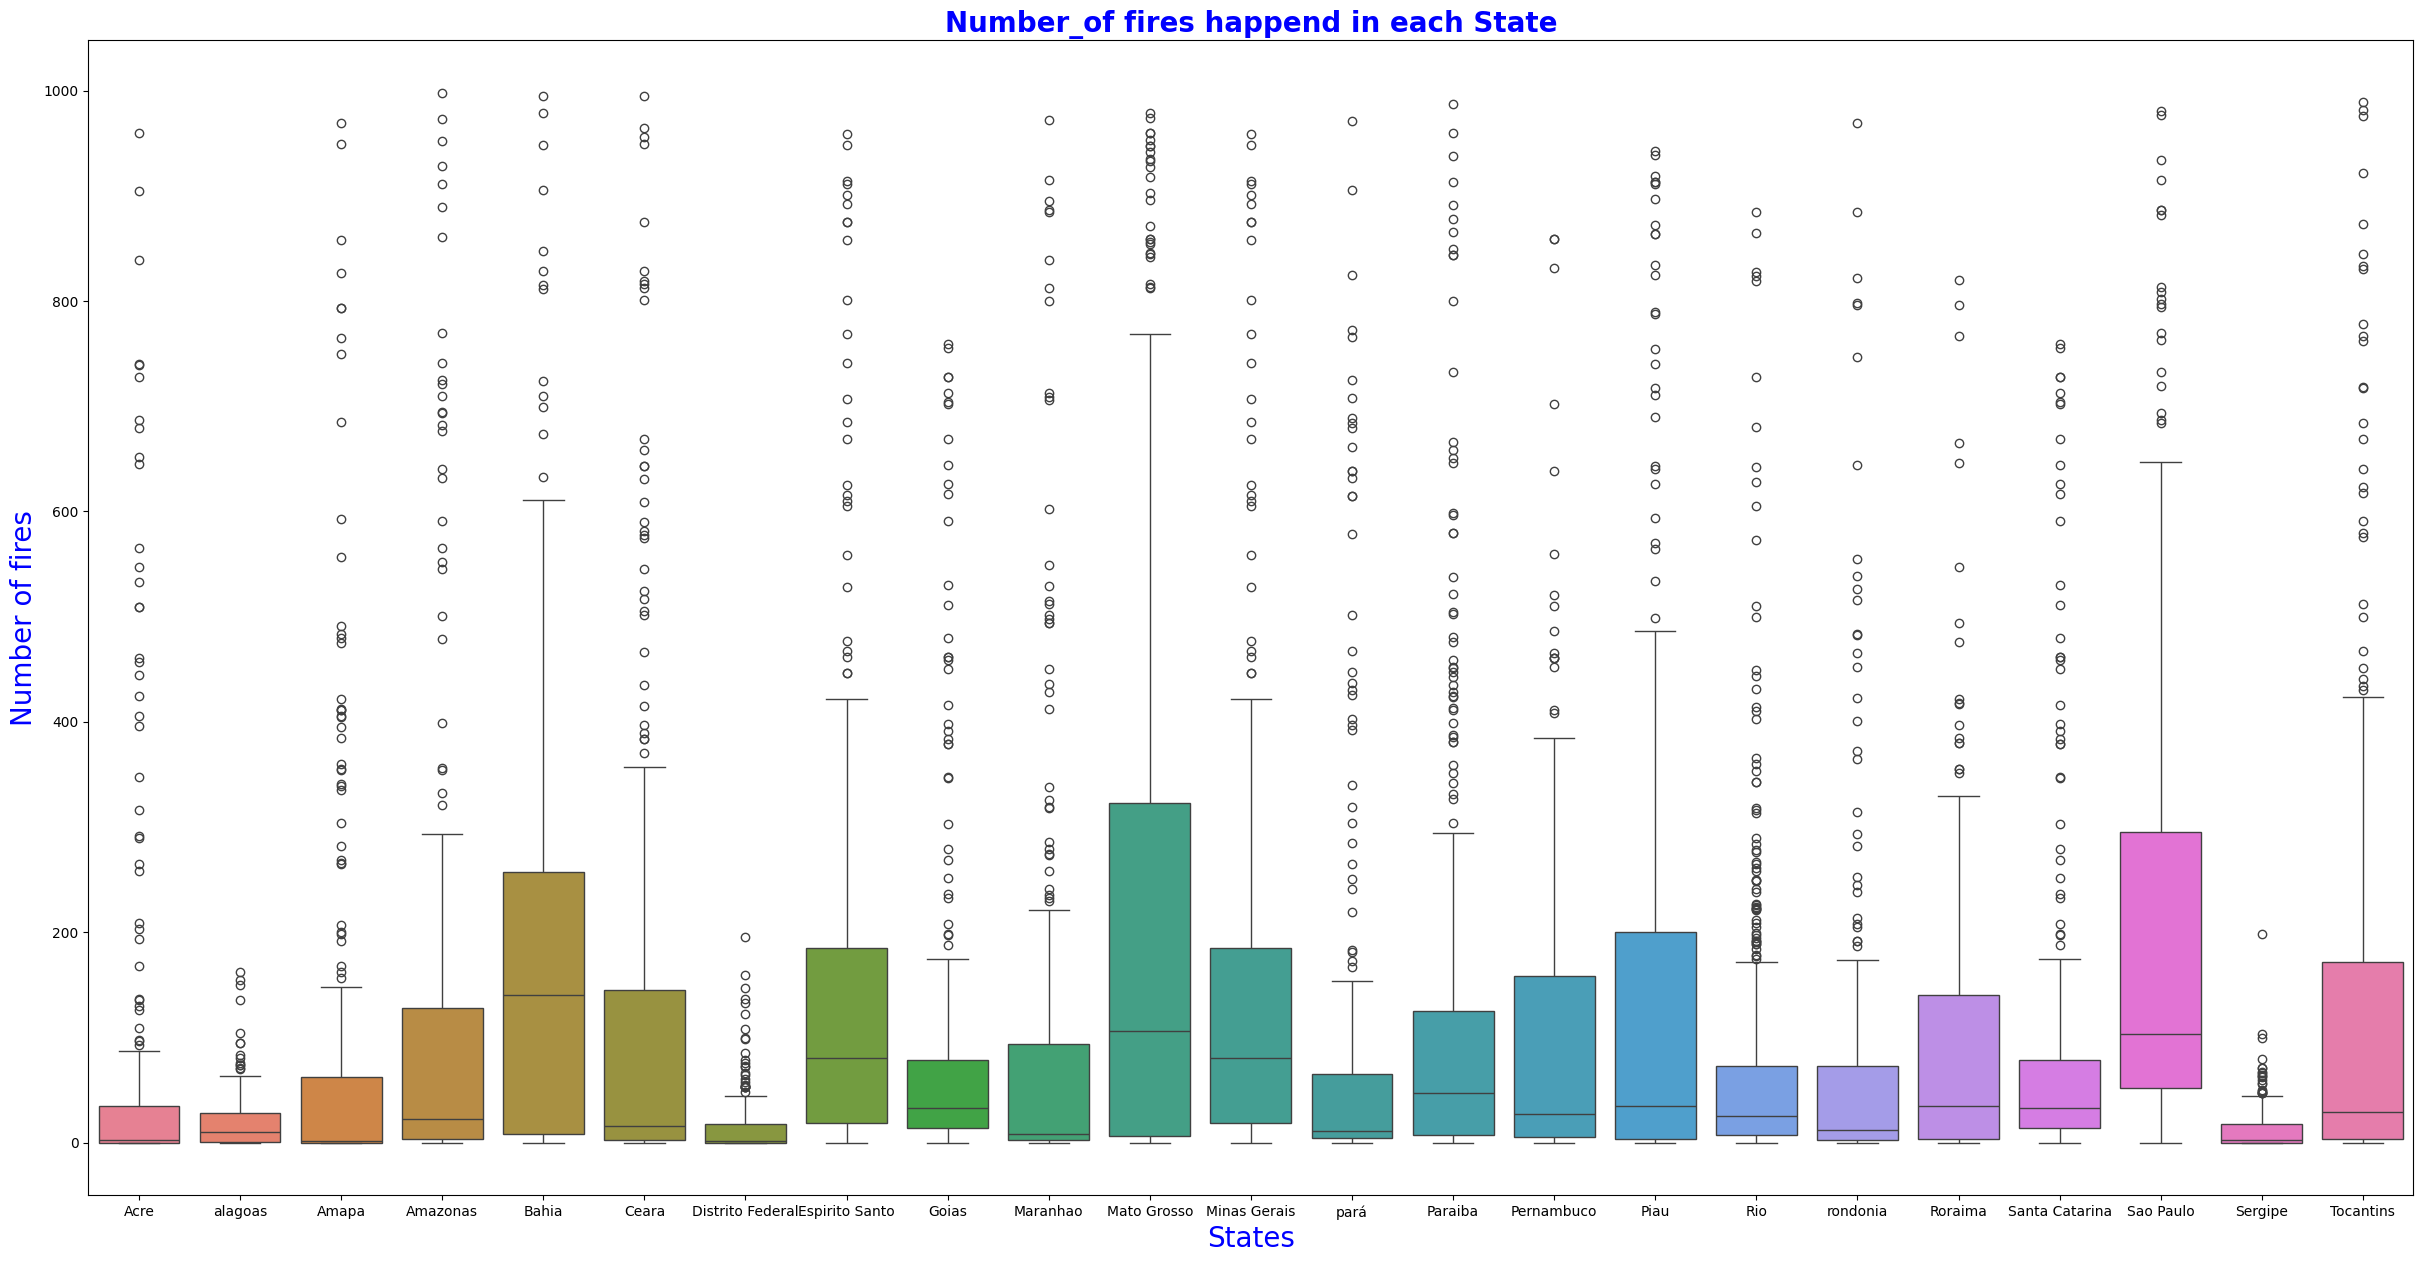

In [91]:
plt.figure(figsize=(30,15))
a=sns.boxplot(x='state',y='no_of_fires',data=df,hue='state')
a.set_xlabel('States',color='blue',fontsize=20)
a.set_ylabel('Number of fires',color='blue',fontsize=20)
a.set_title('Number_of fires happend in each State',color='blue',fontsize=20,fontweight='bold')
plt.show()

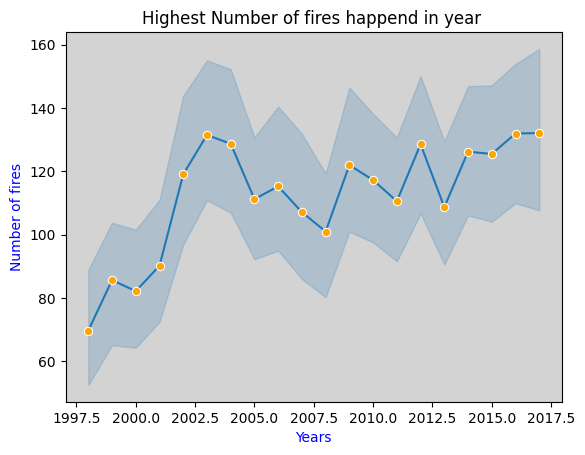

In [90]:
a=sns.lineplot(x='year',y='no_of_fires',data=df,marker='o',markerfacecolor='orange')
a.set_xlabel('Years',color='blue')
a.set_ylabel('Number of fires',color='blue')
a.set_title('Highest Number of fires happend in year')
a.set_facecolor('lightgray')
plt.show()

CONCLUSION


*The analysis of the Amazon fires dataset shows that the highest number of fires occurred between 2002 and 2005.

*Among all months, August recorded the highest number of fire incidents.

*The state of Mato Grosso had the highest number of fires compared to other states.